# Preparação dos Dados

Este notebook apresenta todas as etapas de preparação dos dados utilizadas para a construção do modelo preditivo de abandono do tratamento de tuberculose. Foram realizadas atividades de limpeza, tratamento de inconsistências e valores ausente, criação de atributos, análise e transformação das variáveis.

## Etapas realizadas:

- Tratamento de valores ausentes (missing values)
- Tratamento de outliers utilizando o método IQR
- Seleção de variáveis relevantes para o problema
- Criação de novas variáveis derivadas (score de vulnerabilidade, quantidade de comorbidades e faixa etária)
- Aplicação de filtros e correções em códigos inconsistentes do SINAN
- Normalização das variáveis numéricas
- Codificação das variáveis categóricas
- Construção de um pipeline automatizado de preparação dos dados utilizando Scikit-Learn




In [ ]:
# Importação de libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

import joblib

pd.options.display.float_format = '{:.3f}'.format

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Classe personalizada para detectar e tratar outliers
# utilizando o método IQR, integrada ao Pipeline do Scikit-Learn
class OutlierClipper(BaseEstimator, TransformerMixin):

    # calcula os limites inferior e superior para cada variável
    def fit(self, X, y=None):

        self.lower_bounds_ = []
        self.upper_bounds_ = []

        for j in range(X.shape[1]):

            col = pd.Series(X[:, j]).astype(float)

            Q1 = col.quantile(0.25)
            Q3 = col.quantile(0.75)

            IQR = Q3 - Q1

            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR

            self.lower_bounds_.append(lower)
            self.upper_bounds_.append(upper)

        return self

    # aplica o tratamento de outliers aos dados
    def transform(self, X, y=None):

        X = X.copy().astype(float)

        for j in range(X.shape[1]):

            X[:, j] = np.clip(
                X[:, j],
                self.lower_bounds_[j],
                self.upper_bounds_[j]
            )
        return X

In [ ]:
import pandas as pd
# carregamento dos conjuntos de dados
df_treino = pd.read_csv("/content/drive/MyDrive/treino.csv", low_memory=False)
df_teste1 = pd.read_csv("/content/drive/MyDrive/teste1.csv", low_memory=False)
df_teste2 = pd.read_csv("/content/drive/MyDrive/teste2.csv", low_memory=False)
df_treino.head()

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,NU_IDADE_N,...,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,UF_TRANSF,MUN_TRANSF,idade_unid,idade_val,idade_anos,ltfu
0,2,A169,2003-03-17,2003,11,110010,1483.000,20030317,1978.000,4024,...,0.000,0.000,0,0.000,NaN,NaN,4,24,24,0
1,2,A169,2005-06-10,2005,11,110010,1483.000,20050610,1957.000,4048,...,0.000,0.000,4,0.000,NaN,NaN,4,48,48,0
2,2,A169,2006-02-02,2006,35,355030,1331.000,20051220,1961.000,4044,...,7.000,0.000,1,0.000,NaN,NaN,4,44,44,0
3,2,A169,2006-01-24,2006,35,351640,1334.000,20051117,1980.000,4025,...,7.000,0.000,2,0.000,NaN,NaN,4,25,25,0
4,2,A169,2006-02-22,2006,35,350330,1345.000,20051229,1973.000,4032,...,7.000,0.000,3,0.000,NaN,NaN,4,32,32,0


# Preparação dos Dados

In [ ]:
# Listagem das colunas para orientar a seleção de variáveis
colunas = df_treino.columns

for i in colunas:

  print(i)

TP_NOT
ID_AGRAVO
DT_NOTIFIC
NU_ANO
SG_UF_NOT
ID_MUNICIP
ID_REGIONA
DT_DIAG
ANO_NASC
NU_IDADE_N
CS_SEXO
CS_GESTANT
CS_RACA
CS_ESCOL_N
SG_UF
ID_MN_RESI
ID_RG_RESI
ID_PAIS
NDUPLIC_N
IN_VINCULA
DT_DIGITA
DT_TRANSUS
DT_TRANSDM
DT_TRANSSM
DT_TRANSRM
DT_TRANSRS
DT_TRANSSE
CS_FLXRET
FLXRECEBI
MIGRADO_W
ID_OCUPA_N
TRATAMENTO
INSTITUCIO
RAIOX_TORA
TESTE_TUBE
FORMA
EXTRAPU1_N
EXTRAPU2_N
EXTRAPUL_O
AGRAVAIDS
AGRAVALCOO
AGRAVDIABE
AGRAVDOENC
AGRAVOUTRA
AGRAVOUTDE
BACILOSC_E
BACILOS_E2
BACILOSC_O
CULTURA_ES
CULTURA_OU
HIV
HISTOPATOL
DT_INIC_TR
RIFAMPICIN
ISONIAZIDA
ETAMBUTOL
ESTREPTOMI
PIRAZINAMI
ETIONAMIDA
OUTRAS
OUTRAS_DES
TRAT_SUPER
NU_CONTATO
DOENCA_TRA
SG_UF_AT
ID_MUNIC_A
DT_NOTI_AT
SG_UF_2
ID_MUNIC_2
BACILOSC_1
BACILOSC_2
BACILOSC_3
BACILOSC_4
BACILOSC_5
BACILOSC_6
TRATSUP_AT
DT_MUDANCA
NU_COMU_EX
SITUA_9_M
SITUA_12_M
SITUA_ENCE
DT_ENCERRA
TPUNINOT
POP_LIBER
POP_RUA
POP_SAUDE
POP_IMIG
BENEF_GOV
AGRAVDROGA
AGRAVTABAC
TEST_MOLEC
TEST_SENSI
ANT_RETRO
BAC_APOS_6
TRANSF
UF_TRANSF
MUN_TRANSF
idade_u

In [ ]:
variaveis_selecionadas = [
    "TRATAMENTO",      # tp_entrada
    "POP_RUA",         # tp_pop_rua
    "POP_LIBER",       # tp_pop_liberdade
    "POP_IMIG",        # tp_pop_imigrante
    "BENEF_GOV",       # tp_benef_gov
    "AGRAVALCOO",      # st_agravo_alcolismo
    "AGRAVDROGA",      # st_agravo_drogas
    "AGRAVDOENC",      # st_agravo_mental (aproximação)
    "AGRAVAIDS",       # st_agravo_aids
    "AGRAVDIABE",      # st_agravo_diabete
    "HIV",             # tp_hiv
    "FORMA",           # tp_forma
    "TRAT_SUPER",      # tp_tratamento_acompanhamento
    "idade_anos",      # idade
    "ID_MUNIC_A",      # municipio atual (aproximação)
    "POP_SAUDE",       # tp_pop_saúde
    "TEST_SENSI",      # tp_sensibilidade
    "BACILOSC_2",      # baciloscopia 2º mês (aproximação)
    "CS_ESCOL_N",      # escolaridade
    "CS_SEXO",         # sexo
    "CS_RACA",         # raça (1=Branca, 2=Preta, 3=Amarela, 4=Parda, 5=Indígena)
    "ID_RG_RESI"       # zona (aproximação)
]

cols_vulnerabilidade = [
    'POP_RUA',
    'POP_LIBER',
    'POP_IMIG',
    'AGRAVALCOO',
    'AGRAVDROGA',
    'AGRAVAIDS'
]

cols_comorbidades = [
    'AGRAVAIDS',
    'AGRAVDIABE',
    'AGRAVDOENC'
]

colunas_com_9 = [
    'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV',
    'AGRAVALCOO', 'AGRAVDROGA', 'AGRAVDOENC', 'AGRAVAIDS', 'AGRAVDIABE',
    'TRAT_SUPER', 'HIV', 'TEST_SENSI', 'BACILOSC_2', 'CS_ESCOL_N', 'CS_RACA',
]

cols_binarias_sinan = [
    'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV',
    'AGRAVALCOO', 'AGRAVDROGA', 'AGRAVDOENC', 'AGRAVAIDS', 'AGRAVDIABE',
    'TRAT_SUPER',
]

# seleção e transformação das variáveis
def preparar_df_modelo(df):
    df_modelo = df[variaveis_selecionadas + ["ltfu"]].copy()

    for col in colunas_com_9:
        df_modelo[col] = df_modelo[col].replace({9: np.nan, 9.0: np.nan})

    # regras específicas por coluna

    # TRATAMENTO: 4 = 'Não Sabe' - sem informação útil
    df_modelo['TRATAMENTO'] = df_modelo['TRATAMENTO'].replace({4: np.nan})

    # HIV: 3='Em andamento', 4='Não realizado' - não conclusivos
    df_modelo['HIV'] = df_modelo['HIV'].replace({3: np.nan, 4: np.nan})

    # TEST_SENSI: 6='Em andamento', 7='Não realizado' - não conclusivos
    df_modelo['TEST_SENSI'] = df_modelo['TEST_SENSI'].replace({6: np.nan, 7: np.nan})

    # BACILOSC_2: 3='Não realizada', 4='Não se aplica' - sem informação útil
    df_modelo['BACILOSC_2'] = df_modelo['BACILOSC_2'].replace({3: np.nan, 4: np.nan})

    # BENEF_GOV: apenas 1=Sim e 2=Não são válidos
    df_modelo['BENEF_GOV'] = df_modelo['BENEF_GOV'].replace({
        3: np.nan, 4: np.nan, 5: np.nan
    })

    # AGRAVAIDS / AGRAVDIABE: apenas 1=Sim e 2=Não são válidos; 3 é inconsistência
    df_modelo['AGRAVAIDS'] = df_modelo['AGRAVAIDS'].replace({3: np.nan})
    df_modelo['AGRAVDIABE'] = df_modelo['AGRAVDIABE'].replace({3: np.nan})

    # Conversão das variáveis binárias do SINAN:
    # 1 = Sim
    # 2 = Não → 0
    for col in cols_binarias_sinan:
        df_modelo[col] = df_modelo[col].replace({2: 0, 2.0: 0})

    df_modelo['score_vulnerabilidade'] = (
        df_modelo[cols_vulnerabilidade].fillna(0).sum(axis=1)
    )

    df_modelo['qtd_comorbidades'] = (
        df_modelo[cols_comorbidades].fillna(0).sum(axis=1)
    )

    df_modelo['faixa_etaria'] = pd.cut(
        df_modelo['idade_anos'],
        bins=[18, 30, 45, 60, 120],
        labels=['18-30', '31-45', '46-60', '60+']
    )

    return df_modelo

In [ ]:
treino_modelo = preparar_df_modelo(df_treino)
teste1_modelo = preparar_df_modelo(df_teste1)
teste2_modelo = preparar_df_modelo(df_teste2)

X_train = treino_modelo.drop("ltfu", axis=1)
y_train = treino_modelo["ltfu"]

X_test1 = teste1_modelo.drop("ltfu", axis=1)
y_test1 = teste1_modelo["ltfu"]

X_test2 = teste2_modelo.drop("ltfu", axis=1)
y_test2 = teste2_modelo["ltfu"]

print("Treino:", treino_modelo.shape)
print("Teste1:", teste1_modelo.shape)
print("Teste2:", teste2_modelo.shape)

print("\nTaxa abandono:")
print("Treino :", treino_modelo['ltfu'].mean())
print("Teste1 :", teste1_modelo['ltfu'].mean())
print("Teste2 :", teste2_modelo['ltfu'].mean())

Treino: (562632, 26)
Teste1: (631, 26)
Teste2: (631, 26)

Taxa abandono:
Treino : 0.19418376487650899
Teste1 : 0.43898573692551507
Teste2 : 0.694136291600634


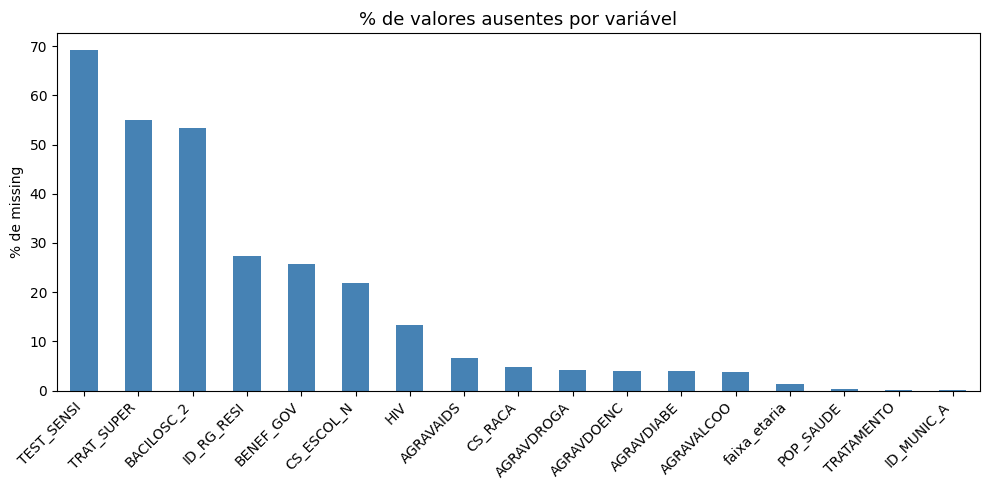

TEST_SENSI     69.300
TRAT_SUPER     55.000
BACILOSC_2     53.300
ID_RG_RESI     27.300
BENEF_GOV      25.600
CS_ESCOL_N     21.900
HIV            13.400
AGRAVAIDS       6.600
CS_RACA         4.800
AGRAVDROGA      4.200
AGRAVDOENC      4.100
AGRAVDIABE      3.900
AGRAVALCOO      3.800
faixa_etaria    1.400
POP_SAUDE       0.300
TRATAMENTO      0.200
ID_MUNIC_A      0.000


In [ ]:
# Análise da proporção de valores ausentes em cada variável
missing = treino_modelo.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='steelblue')
plt.title('% de valores ausentes por variável', fontsize=13)
plt.ylabel('% de missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(missing.round(1).to_string())

In [ ]:
# Conversão das variáveis binárias do SINAN para representação numérica
cols_binarias_sinan = [
    'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV',
    'AGRAVALCOO', 'AGRAVDROGA', 'AGRAVDOENC', 'AGRAVAIDS', 'AGRAVDIABE',
    'TRAT_SUPER',
]

for col in cols_binarias_sinan:
    treino_modelo[col] = treino_modelo[col].replace({2: 0, 2.0: 0})

# Verificação: cada coluna deve ter apenas 0.0, 1.0 e NaN
print('Valores únicos após conversão (sem NaN):')
for col in cols_binarias_sinan:
    unicos = sorted(treino_modelo[col].dropna().unique())
    print(f'  {col:15s}: {unicos}')

Valores únicos após conversão (sem NaN):
  POP_RUA        : [np.int64(0), np.int64(1)]
  POP_LIBER      : [np.int64(0), np.int64(1)]
  POP_IMIG       : [np.int64(0), np.int64(1)]
  POP_SAUDE      : [np.float64(0.0)]
  BENEF_GOV      : [np.float64(0.0), np.float64(1.0)]
  AGRAVALCOO     : [np.float64(0.0), np.float64(1.0)]
  AGRAVDROGA     : [np.float64(0.0), np.float64(1.0)]
  AGRAVDOENC     : [np.float64(0.0), np.float64(1.0)]
  AGRAVAIDS      : [np.float64(0.0), np.float64(1.0)]
  AGRAVDIABE     : [np.float64(0.0), np.float64(1.0)]
  TRAT_SUPER     : [np.float64(0.0), np.float64(1.0)]


In [ ]:
# Separação das variáveis conforme o tipo de dado

# Variáveis numéricas contínuas
cols_numericas = [
    'idade_anos',
    'score_vulnerabilidade',
    'qtd_comorbidades'
]

# Variáveis binárias
cols_binarias_sinan = [
    'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV',
    'AGRAVALCOO', 'AGRAVDROGA', 'AGRAVDOENC', 'AGRAVAIDS', 'AGRAVDIABE',
    'TRAT_SUPER',
]

# Variáveis categóricas
cols_categoricas = [
    'CS_SEXO',      # M / F / I
    'CS_RACA',      # 1=Branca, 2=Preta, 3=Amarela, 4=Parda, 5=Indígena
    'FORMA',        # 1=Pulmonar, 2=Extrapulmonar, 3=Ambas
    'TRATAMENTO',   # 1=Caso novo, 2=Recidiva, 3=Reingresso, 5=Transferência, 6=Pós-óbito
    'HIV',          # 1=Positivo, 2=Negativo
    'TEST_SENSI',   # 1-5: diferentes padrões de resistência / 5=Sensível
    'BACILOSC_2',   # 1=Positiva, 2=Negativa
    'CS_ESCOL_N',   # escolaridade (ordinal)
    'faixa_etaria'
]

# Variáveis relacionadas à localização geográfica
cols_municipio = ['ID_MUNIC_A', 'ID_RG_RESI']


all_features = cols_numericas + cols_binarias_sinan + cols_categoricas + cols_municipio
print(f'Total de features: {len(all_features)}')
print('\nFeatures:', all_features)

Total de features: 25

Features: ['idade_anos', 'score_vulnerabilidade', 'qtd_comorbidades', 'POP_RUA', 'POP_LIBER', 'POP_IMIG', 'POP_SAUDE', 'BENEF_GOV', 'AGRAVALCOO', 'AGRAVDROGA', 'AGRAVDOENC', 'AGRAVAIDS', 'AGRAVDIABE', 'TRAT_SUPER', 'CS_SEXO', 'CS_RACA', 'FORMA', 'TRATAMENTO', 'HIV', 'TEST_SENSI', 'BACILOSC_2', 'CS_ESCOL_N', 'faixa_etaria', 'ID_MUNIC_A', 'ID_RG_RESI']


# Construção do Pipeline de Pré-Processamento

In [ ]:
# Codificação de municípios e regiões utilizando frequência de ocorrência
# Municípios mais frequentes recebem códigos menores e valores não vistos durante o treinamento recebem uma categoria extra
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.maps_ = []
        for j in range(X.shape[1]):
            col = pd.Series(X[:, j]).fillna('desconhecido').astype(str)
            freq = col.value_counts()
            self.maps_.append({val: rank for rank, val in enumerate(freq.index)})
        return self

    def transform(self, X, y=None):
        result = np.zeros((X.shape[0], X.shape[1]))
        for j in range(X.shape[1]):
            col = pd.Series(X[:, j]).fillna('desconhecido').astype(str)
            result[:, j] = col.map(self.maps_[j]).fillna(len(self.maps_[j]))
        return result

print('Codificador de frequência definido')

Codificador de frequência definido


In [ ]:
# Sub-pipeline para numéricas: imputa mediana
pipe_num = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('outlier', OutlierClipper()),
    ('scaler', StandardScaler()),
])

# Sub-pipeline para binárias: imputa moda
pipe_bin = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

# Sub-pipeline para categóricas: imputa moda
pipe_cat = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
])

# Sub-pipeline para variáveis geográficas
pipe_mun = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=np.nan)),
    ('encoder', FrequencyEncoder()),
])

# Combina todas as etapas de pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', pipe_num, cols_numericas),
        ('bin', pipe_bin, cols_binarias_sinan),
        ('cat', pipe_cat, cols_categoricas),
        ('mun', pipe_mun, cols_municipio),
    ],
    remainder='drop'
)

print('Pipeline configurado com sucesso')

Pipeline configurado com sucesso


In [ ]:
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_test1_proc = preprocessor.transform(X_test1)
X_test2_proc = preprocessor.transform(X_test2)

print(f'Shape treino processado: {X_train_proc.shape}')
print(f'Shape teste1 processado: {X_test1_proc.shape}')
print(f'Shape teste2 processado: {X_test2_proc.shape}')

print(f'\nNaN restantes — Treino: {np.isnan(X_train_proc).sum()} | Teste1: {np.isnan(X_test1_proc).sum()} | Teste2: {np.isnan(X_test2_proc).sum()}')

Shape treino processado: (562632, 25)
Shape teste1 processado: (631, 25)
Shape teste2 processado: (631, 25)

NaN restantes — Treino: 0 | Teste1: 0 | Teste2: 0


# Aplicação do Pipeline



In [ ]:
# Recriar como DataFrame para facilitar análises
col_names = cols_numericas + cols_binarias_sinan + cols_categoricas + cols_municipio

X_train_df = pd.DataFrame(X_train_proc, columns=col_names)
X_test1_df = pd.DataFrame(X_test1_proc, columns=col_names)
X_test2_df = pd.DataFrame(X_test2_proc, columns=col_names)

print('Primeiras linhas do treino processado:')
display(X_train_df.head())

Primeiras linhas do treino processado:


,idade_anos,score_vulnerabilidade,qtd_comorbidades,POP_RUA,POP_LIBER,POP_IMIG,POP_SAUDE,BENEF_GOV,AGRAVALCOO,AGRAVDROGA,...,CS_RACA,FORMA,TRATAMENTO,HIV,TEST_SENSI,BACILOSC_2,CS_ESCOL_N,faixa_etaria,ID_MUNIC_A,ID_RG_RESI
0,-1.044,-0.764,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,5.000,0.000,0.000,2.000,0.000,2.000,3.000,0.000,406.000,59.000
1,0.490,-0.764,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,5.000,0.000,0.000,2.000,0.000,2.000,0.000,2.000,406.000,59.000
2,0.234,0.502,0.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,...,1.000,0.000,0.000,2.000,1.000,0.000,3.000,1.000,1.000,9.000
3,-0.980,0.502,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,2.000,1.000,2.000,3.000,0.000,70.000,113.000
4,-0.533,-0.764,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,2.000,0.000,0.000,2.000,1.000,2.000,9.000,1.000,257.000,71.000


# Análise Exploratória dos Dados

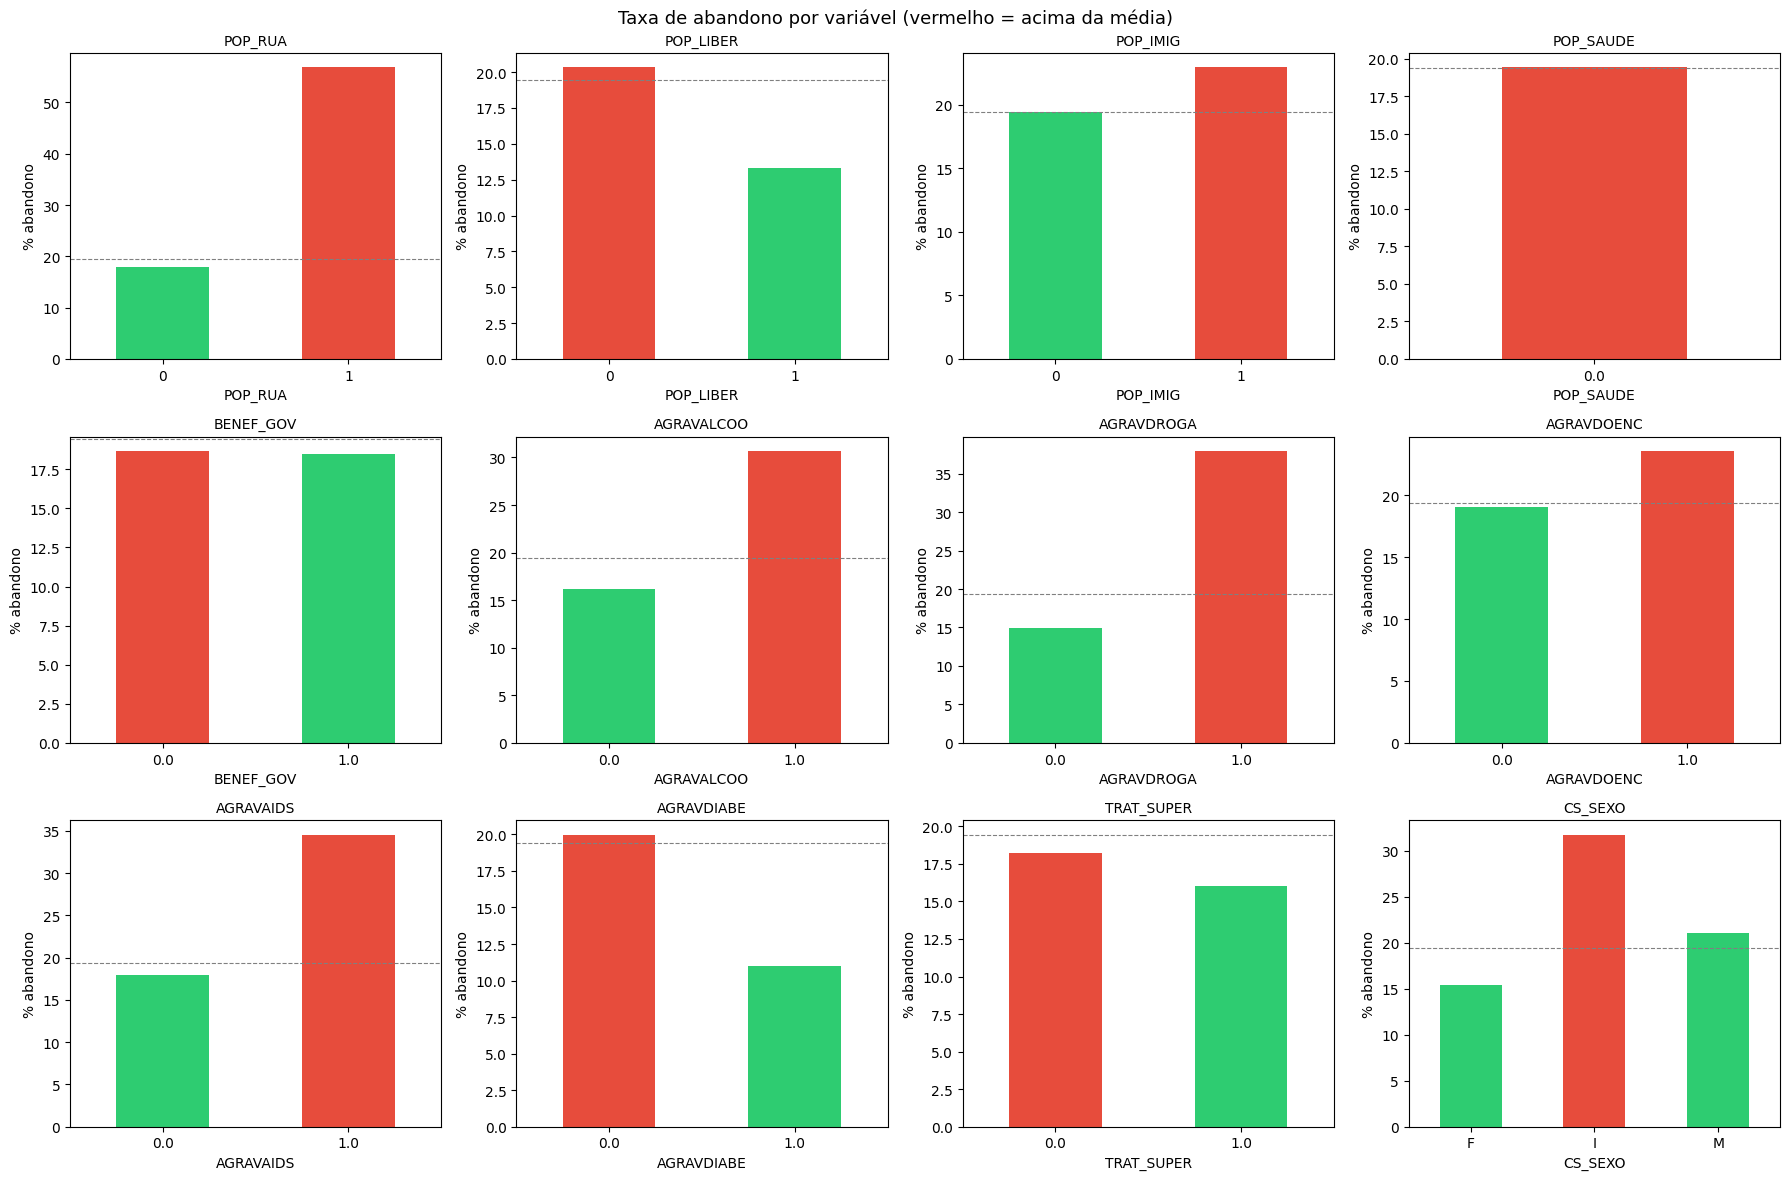

In [ ]:
TARGET = 'ltfu'

# Taxa de abandono por variáveis
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(cols_binarias_sinan + ['CS_SEXO']):
    taxa = treino_modelo.groupby(col)[TARGET].mean() * 100
    cores = ['#2ecc71' if v < taxa.mean() else '#e74c3c' for v in taxa]
    taxa.plot(kind='bar', ax=axes[i], color=cores)
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_ylabel('% abandono')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].axhline(treino_modelo[TARGET].mean()*100, color='gray', linestyle='--', linewidth=0.8, label='média geral')

for j in range(len(cols_binarias_sinan)+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Taxa de abandono por variável (vermelho = acima da média)', fontsize=13)
plt.tight_layout()
plt.show()

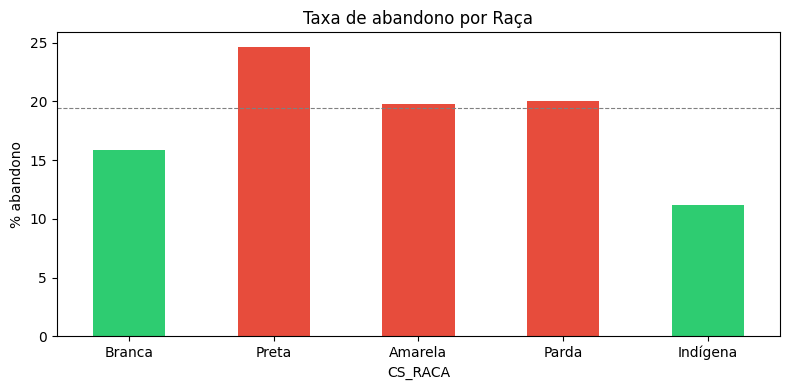

In [ ]:
# Taxa de abandono por raça
raca_labels = {1: 'Branca', 2: 'Preta', 3: 'Amarela', 4: 'Parda', 5: 'Indígena'}
df_raca = treino_modelo[treino_modelo['CS_RACA'].isin([1, 2, 3, 4, 5])].copy()
df_raca['CS_RACA'] = df_raca['CS_RACA'].astype(int)
taxa_raca = df_raca.groupby('CS_RACA')[TARGET].mean() * 100
taxa_raca.index = taxa_raca.index.map(raca_labels)
cores_raca = ['#2ecc71' if v < taxa_raca.mean() else '#e74c3c' for v in taxa_raca]
taxa_raca.plot(kind='bar', color=cores_raca, figsize=(8, 4))
plt.title('Taxa de abandono por Raça', fontsize=12)
plt.ylabel('% abandono')
plt.xticks(rotation=0)
plt.axhline(treino_modelo[TARGET].mean()*100, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

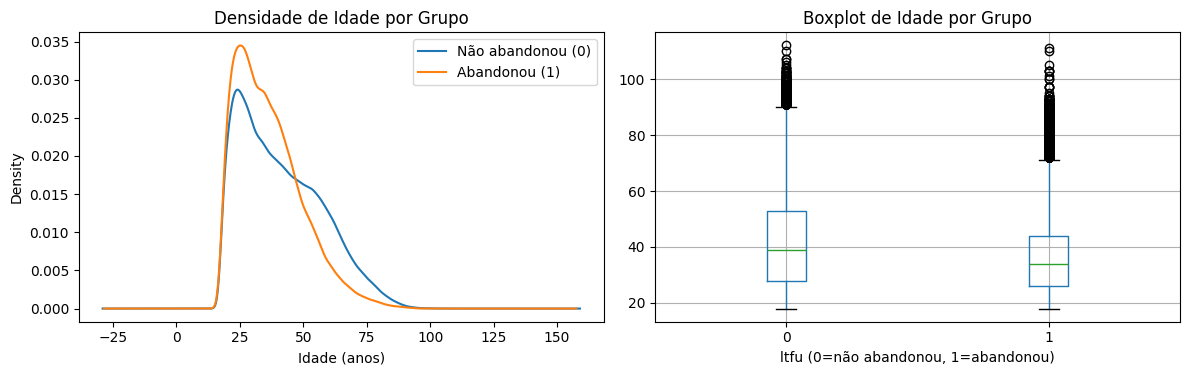

Média de idade por grupo:
ltfu
0   41.257
1   36.567
Name: idade_anos, dtype: float64

Crosstab CS_SEXO × ltfu:
ltfu        0     1
CS_SEXO            
F       0.846 0.154
I       0.683 0.317
M       0.790 0.210

Crosstab CS_RACA × ltfu:
ltfu        0     1
CS_RACA            
0.000   0.857 0.143
1.000   0.841 0.159
2.000   0.753 0.247
3.000   0.802 0.198
4.000   0.800 0.200
5.000   0.888 0.112
6.000   1.000 0.000


In [ ]:
# Distribuição da idade por grupo
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

treino_modelo.groupby(TARGET)['idade_anos'].plot(
    kind='density', ax=axes[0]
)
axes[0].set_title('Densidade de Idade por Grupo')
axes[0].set_xlabel('Idade (anos)')
axes[0].legend(['Não abandonou (0)', 'Abandonou (1)'])

treino_modelo.boxplot(column='idade_anos', by=TARGET, ax=axes[1])
axes[1].set_title('Boxplot de Idade por Grupo')
axes[1].set_xlabel('ltfu (0=não abandonou, 1=abandonou)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print('Média de idade por grupo:')
print(treino_modelo.groupby(TARGET)['idade_anos'].mean())

print('\nCrosstab CS_SEXO × ltfu:')
print(pd.crosstab(treino_modelo["CS_SEXO"], treino_modelo["ltfu"], normalize="index"))

print('\nCrosstab CS_RACA × ltfu:')
print(pd.crosstab(treino_modelo["CS_RACA"], treino_modelo["ltfu"], normalize="index"))

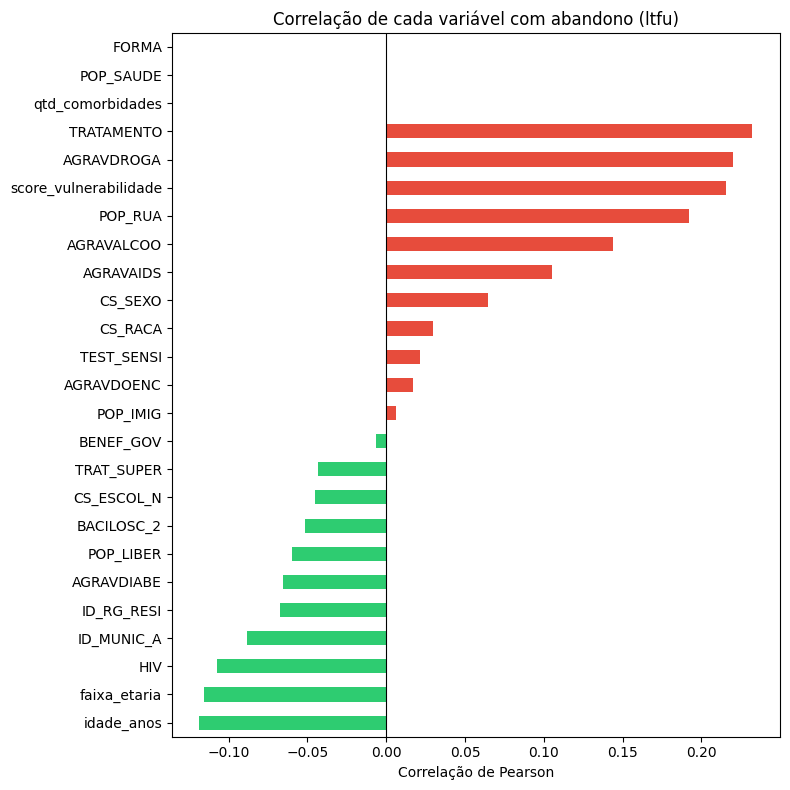

In [ ]:
# Correlação das variáveis com a variável alvo
X_train_df['ltfu'] = y_train.values
corr = X_train_df.corr()['ltfu'].drop('ltfu').sort_values()
plt.figure(figsize=(8, 8))
corr.plot(kind='barh', color=corr.map(lambda v: '#e74c3c' if v > 0 else '#2ecc71'))
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlação de cada variável com abandono (ltfu)', fontsize=12)
plt.xlabel('Correlação de Pearson')
plt.tight_layout()
plt.show()
X_train_df = X_train_df.drop(columns='ltfu')

In [ ]:
X_train_df = pd.DataFrame(X_train_proc, columns=col_names)
X_test1_df = pd.DataFrame(X_test1_proc, columns=col_names)
X_test2_df = pd.DataFrame(X_test2_proc, columns=col_names)

X_train_df.to_csv('/content/drive/MyDrive/X_train_proc.csv', index=False)
X_test1_df.to_csv('/content/drive/MyDrive/X_test1_proc.csv', index=False)
X_test2_df.to_csv('/content/drive/MyDrive/X_test2_proc.csv', index=False)

y_train.reset_index(drop=True).to_csv('/content/drive/MyDrive/y_train.csv', index=False)
y_test1.reset_index(drop=True).to_csv('/content/drive/MyDrive/y_test1.csv', index=False)
y_test2.reset_index(drop=True).to_csv('/content/drive/MyDrive/y_test2.csv', index=False)

joblib.dump(preprocessor, '/content/drive/MyDrive/preprocessor.pkl')

['/content/drive/MyDrive/preprocessor.pkl']